# 🫀 Heart Disease Prediction with Logistic Regression
**Mini-Project | UCI Heart Disease Dataset**

This notebook walks through the full ML pipeline:
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
3. Model Training (Logistic Regression)
4. Model Evaluation

## 0. Imports & Setup

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)

print('All libraries imported successfully ')

All libraries imported successfully 


## 1. Load the Dataset

The UCI Heart Disease (Cleveland) dataset contains **303 patients** and **13 clinical features**.

| Column | Description |
|--------|-------------|
| `age` | Age in years |
| `sex` | Sex (1=male, 0=female) |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1=true) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1=yes) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment (0–2) |
| `ca` | Number of major vessels (0–3) coloured by fluoroscopy |
| `thal` | Thalassemia (0=normal; 1=fixed defect; 2=reversable defect) |
| `target` | **Heart disease present** (1=yes, 0=no) |

In [7]:
# ── Load dataset ──
# If running on Colab, upload 'heart.csv' first or use:
# from google.colab import files; files.upload()

df = pd.read_csv('heart_disease_uci.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 2. Exploratory Data Analysis (EDA)

In [8]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [9]:
# Statistical summary
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id,920.0,460.50,265.73,1.0,230.75,460.5,690.25,920.0
age,920.0,53.51,9.42,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.13,19.07,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.13,110.78,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.55,25.93,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.88,1.09,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.68,0.94,0.0,0.00,0.0,1.00,3.0
num,920.0,1.00,1.14,0.0,0.00,1.0,2.00,4.0


In [16]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Missing values:')
print(missing if not missing.empty else 'None found')

Missing values:
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64


KeyError: 'target'

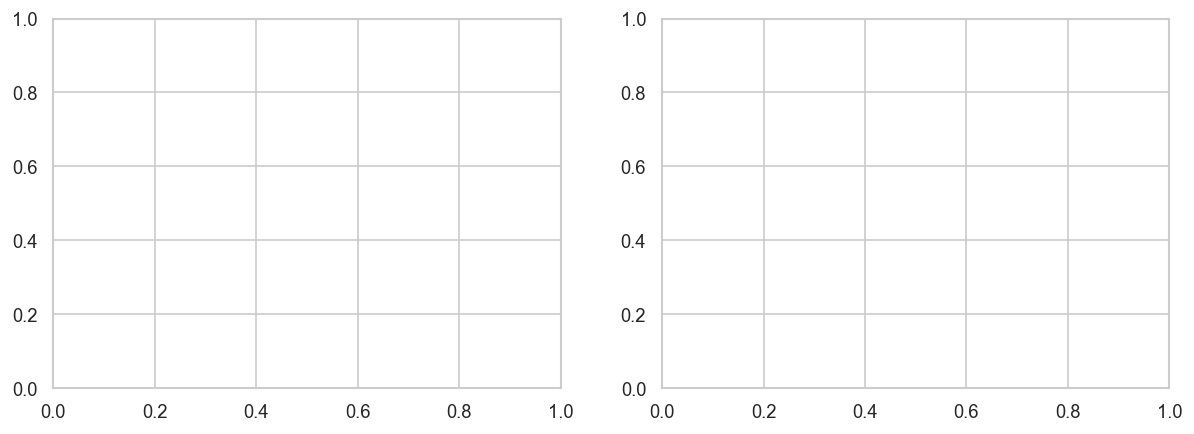

In [17]:
# ── Target distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
            color=['#5DA5DA', '#F15854'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Disease', 'Disease'],
            colors=['#5DA5DA', '#F15854'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Target Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()
print(f'Class balance — No Disease: {counts[0]}, Disease: {counts[1]}')

KeyError: 'target'

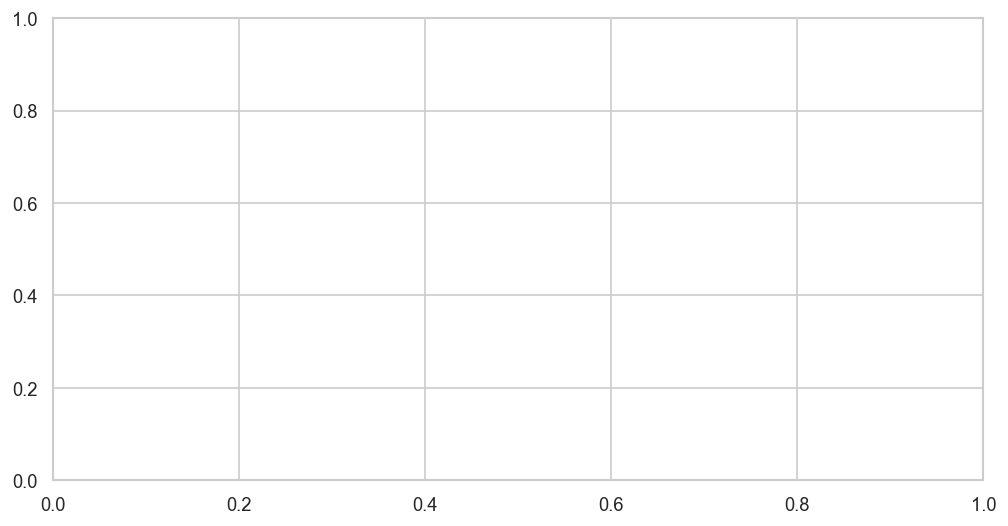

In [18]:
# ── Age distribution by target ──
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in zip([0, 1], ['#5DA5DA', '#F15854']):
    ax.hist(df[df['target'] == label]['age'], bins=20, alpha=0.6,
            label=f'Target={label}', color=color, edgecolor='white')
ax.set_title('Age Distribution by Heart Disease Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('age_distribution.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Correlation heatmap ──
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Categorical features vs Target ──
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#5DA5DA', '#F15854'],
            edgecolor='white', linewidth=0.8, legend=(i == 0))
    axes[i].set_title(f'{col} vs Target', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('% Patients')
    axes[i].tick_params(axis='x', rotation=0)

axes[-1].set_visible(False)
fig.suptitle('Categorical Features vs Heart Disease', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('categorical_features.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Numerical features boxplot by target ──
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    data_0 = df[df['target'] == 0][col].dropna()
    data_1 = df[df['target'] == 1][col].dropna()
    bp = ax.boxplot([data_0, data_1], patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#5DA5DA')
    bp['boxes'][1].set_facecolor('#F15854')
    ax.set_title(col, fontweight='bold')
    ax.set_xticklabels(['No Disease', 'Disease'], fontsize=9)

fig.suptitle('Numerical Features by Heart Disease Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_features.png', bbox_inches='tight')
plt.show()

## 3. Data Preprocessing

Steps:
1. Handle missing values (median imputation for numerical columns)
2. Encode categorical variables where needed
3. Feature / target split
4. Train/test split (80/20)
5. Feature scaling (StandardScaler)

In [ ]:
# ── Handle missing values ──
print('Missing values before imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])

for col in df.columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Imputed "{col}" with median = {median_val}')

print(f'\nMissing values after imputation: {df.isnull().sum().sum()}')

In [ ]:
# ── Feature / Target split ──
X = df.drop('target', axis=1)
y = df['target']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Feature columns: {list(X.columns)}')

In [ ]:
# ── Train / Test split (80/20, stratified) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train set: {X_train.shape[0]} samples')
print(f'Test  set: {X_test.shape[0]} samples')
print(f'Train target distribution: {y_train.value_counts().to_dict()}')
print(f'Test  target distribution: {y_test.value_counts().to_dict()}')

In [ ]:
# ── Feature Scaling ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Feature scaling complete ✅')
print(f'Train mean (post-scale): {X_train_scaled.mean():.4f}')
print(f'Train std  (post-scale): {X_train_scaled.std():.4f}')

## 4. Model Training — Logistic Regression

Logistic Regression is well-suited for binary classification. It models the **probability**
that a patient has heart disease using a sigmoid function applied to a linear combination of features.

In [ ]:
# ── Train Logistic Regression ──
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
lr.fit(X_train_scaled, y_train)

print('Model trained successfully ✅')

In [ ]:
# ── Feature coefficients (importance) ──
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#F15854' if c > 0 else '#5DA5DA' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression Coefficients (Feature Importance)', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('feature_coefficients.png', bbox_inches='tight')
plt.show()
print('Red = increases risk | Blue = decreases risk')

## 5. Model Evaluation

We evaluate using:
- **Accuracy** – overall correct predictions
- **Precision** – of predicted positives, how many are truly positive
- **Recall** – of actual positives, how many were correctly identified *(important in medicine!)*
- **F1 Score** – harmonic mean of precision and recall
- **Confusion Matrix** – visual breakdown of predictions
- **ROC Curve** – trade-off between sensitivity and specificity

In [ ]:
# ── Predictions ──
y_pred      = lr.predict(X_test_scaled)
y_pred_prob = lr.predict_proba(X_test_scaled)[:, 1]

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [acc, prec, rec, f1]
})
metrics['Score'] = metrics['Score'].map(lambda x: f'{x:.4f}')
print(metrics.to_string(index=False))

In [ ]:
# ── Metrics Bar Chart ──
scores = [acc, prec, rec, f1]
labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors_m = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, scores, color=colors_m, edgecolor='white', linewidth=1.5, width=0.5)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, label='0.80 threshold')
ax.legend()
plt.tight_layout()
plt.savefig('metrics.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Disease', 'Predicted: Disease'],
            yticklabels=['Actual: No Disease', 'Actual: Disease'],
            linewidths=2, linecolor='white', ax=ax,
            annot_kws={'size': 16, 'fontweight': 'bold'})
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

print(f'True Positives (TP)  : {tp}')
print(f'True Negatives (TN)  : {tn}')
print(f'False Positives (FP) : {fp}  ← predicted disease, actually healthy')
print(f'False Negatives (FN) : {fn}  ← missed disease cases ⚠️')

In [ ]:
# ── Classification Report ──
print('Classification Report')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

In [ ]:
# ── ROC Curve ──
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#E15759', lw=2.5,
        label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='#E15759')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curve — Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('roc_curve.png', bbox_inches='tight')
plt.show()
print(f'AUC Score: {roc_auc:.4f}')

## 6. Summary & Conclusions

### Model Performance

| Metric | Interpretation |
|--------|---------------|
| **Accuracy** | Overall fraction of correct predictions |
| **Precision** | When model predicts disease, how often it's right |
| **Recall** | Of all actual disease cases, how many were caught |
| **F1 Score** | Balance between precision and recall |
| **AUC-ROC** | Probability model ranks a disease patient higher than a healthy one |

### Key Clinical Insight
In a medical context, **Recall (sensitivity) is the most critical metric**. A False Negative (missing a disease case) is more dangerous than a False Positive (unnecessary follow-up).

### Potential Improvements
- Try ensemble methods (Random Forest, XGBoost) for higher accuracy
- Apply SMOTE if class imbalance is significant
- Hyperparameter tuning with GridSearchCV (C, penalty, solver)
- Cross-validation (k-fold) for more robust performance estimates
- Feature selection to reduce noise